# Lab 4.17: Random Forests & EL Boosting

I've already done random forrests to death previously, so I feel very comfortable with them. I'll be moving onto the boosting and bagging excercies straight away

## Boosting

Build an AdaBoost classifier for the Iris dataset using decision tree stumps as weak learners, then evaluate performance with accuracy, cross-validation, a classification report, and a confusion matrix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=13,
    stratify=y
)

In [4]:
base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=13
)

ada_clf = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=50,
    learning_rate=0.5,
    random_state=13
)

ada_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=13)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",13
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [5]:
y_train_pred = ada_clf.predict(X_train)
y_test_pred = ada_clf.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"AdaBoost Training Accuracy: {train_accuracy:.3f}")
print(f"AdaBoost Test Accuracy:     {test_accuracy:.3f}")

AdaBoost Training Accuracy: 0.973
AdaBoost Test Accuracy:     0.974


In [6]:
cv_scores = cross_val_score(
    ada_clf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy:          {cv_scores.mean():.3f}")
print(f"CV Standard Deviation:     {cv_scores.std():.3f}")

5-Fold CV Accuracy Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean CV Accuracy:          0.960
CV Standard Deviation:     0.025


In [7]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.92      0.96        12
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



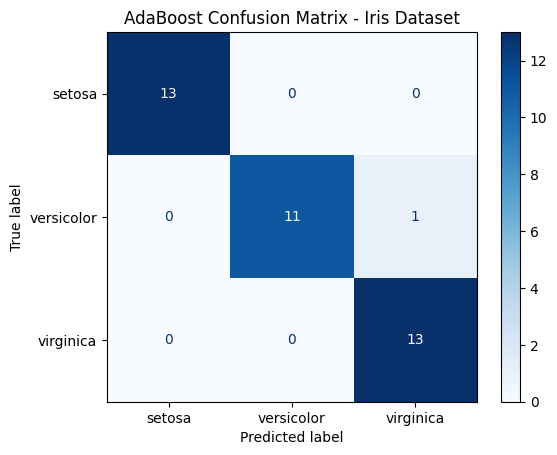

In [8]:
ConfusionMatrixDisplay.from_estimator(
    ada_clf,
    X_test,
    y_test,
    display_labels=iris.target_names,
    cmap="Blues"
)

plt.title("AdaBoost Confusion Matrix - Iris Dataset")
plt.show()

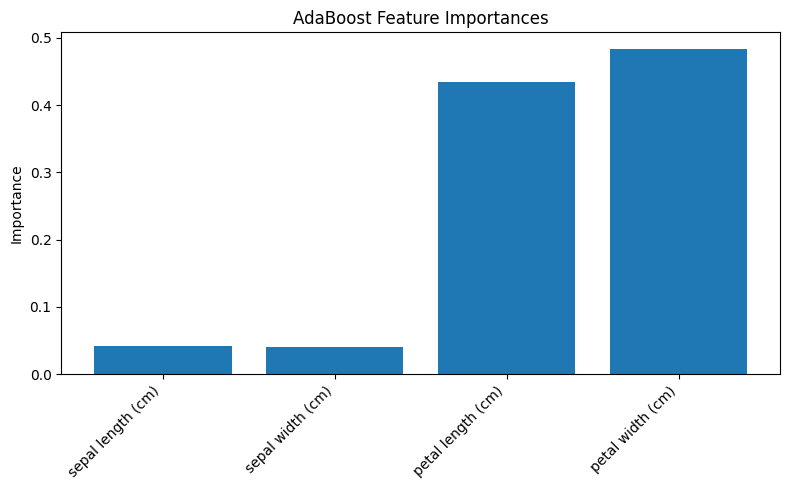

In [9]:
feature_importances = ada_clf.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(iris.feature_names, feature_importances)
plt.title("AdaBoost Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Gradient Boost

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

In [11]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=13
)

gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [12]:
gb_y_train_pred = gb_clf.predict(X_train)
gb_y_test_pred = gb_clf.predict(X_test)

gb_train_accuracy = accuracy_score(y_train, gb_y_train_pred)
gb_test_accuracy = accuracy_score(y_test, gb_y_test_pred)

print(f"Gradient Boosting Training Accuracy: {gb_train_accuracy:.3f}")
print(f"Gradient Boosting Test Accuracy:     {gb_test_accuracy:.3f}")

Gradient Boosting Training Accuracy: 1.000
Gradient Boosting Test Accuracy:     0.947


In [13]:
gb_cv_scores = cross_val_score(
    gb_clf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(f"5-Fold CV Accuracy Scores: {gb_cv_scores}")
print(f"Mean CV Accuracy:          {gb_cv_scores.mean():.3f}")
print(f"CV Standard Deviation:     {gb_cv_scores.std():.3f}")

5-Fold CV Accuracy Scores: [0.96666667 0.96666667 0.9        0.96666667 1.        ]
Mean CV Accuracy:          0.960
CV Standard Deviation:     0.033


In [14]:
print(classification_report(
    y_test,
    gb_y_test_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.83      0.91        12
   virginica       0.87      1.00      0.93        13

    accuracy                           0.95        38
   macro avg       0.96      0.94      0.95        38
weighted avg       0.95      0.95      0.95        38



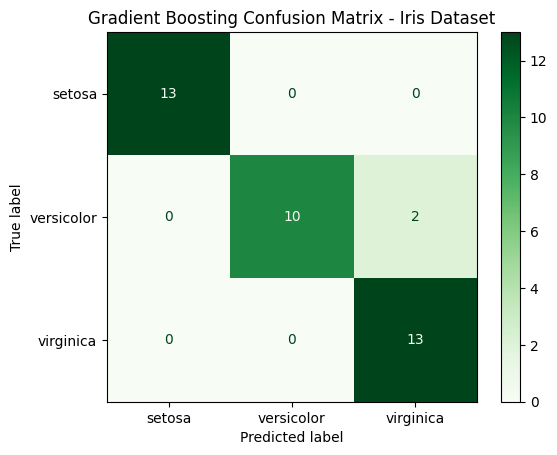

In [15]:
ConfusionMatrixDisplay.from_estimator(
    gb_clf,
    X_test,
    y_test,
    display_labels=iris.target_names,
    cmap="Greens"
)

plt.title("Gradient Boosting Confusion Matrix - Iris Dataset")
plt.show()

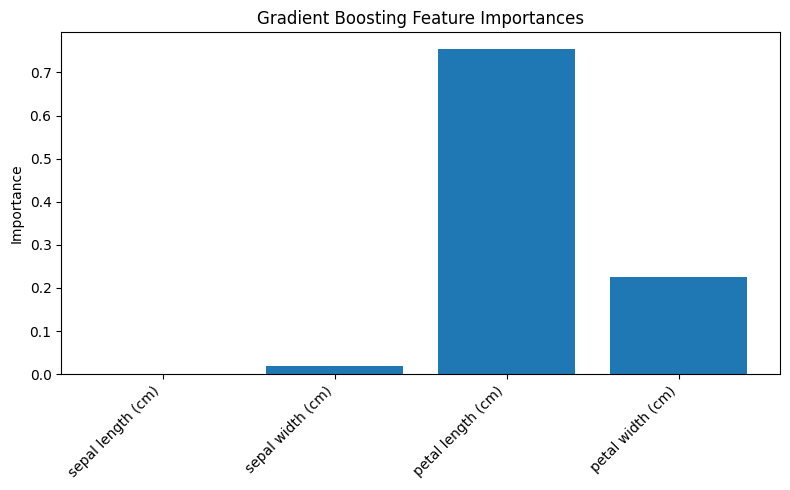

In [16]:
gb_feature_importances = gb_clf.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(iris.feature_names, gb_feature_importances)
plt.title("Gradient Boosting Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Ensemble Regression

In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [18]:
california = fetch_california_housing()

X_reg = california.data
y_reg = california.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=13
)

In [19]:
gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=13
)

gb_reg.fit(X_reg_train, y_reg_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [24]:
gb_reg_train_pred = gb_reg.predict(X_reg_train)
gb_reg_test_pred = gb_reg.predict(X_reg_test)

gb_reg_train_rmse = root_mean_squared_error(y_reg_train, gb_reg_train_pred)
gb_reg_test_rmse = root_mean_squared_error(y_reg_test, gb_reg_test_pred)

gb_reg_train_mae = mean_absolute_error(y_reg_train, gb_reg_train_pred)
gb_reg_test_mae = mean_absolute_error(y_reg_test, gb_reg_test_pred)

gb_reg_train_r2 = r2_score(y_reg_train, gb_reg_train_pred)
gb_reg_test_r2 = r2_score(y_reg_test, gb_reg_test_pred)

print(f"Gradient Boosting Regression Training RMSE: {gb_reg_train_rmse:.3f}")
print(f"Gradient Boosting Regression Test RMSE:     {gb_reg_test_rmse:.3f}")
print(f"Gradient Boosting Regression Training MAE:  {gb_reg_train_mae:.3f}")
print(f"Gradient Boosting Regression Test MAE:      {gb_reg_test_mae:.3f}")
print(f"Gradient Boosting Regression Training R²:   {gb_reg_train_r2:.3f}")
print(f"Gradient Boosting Regression Test R²:       {gb_reg_test_r2:.3f}")

Gradient Boosting Regression Training RMSE: 0.464
Gradient Boosting Regression Test RMSE:     0.516
Gradient Boosting Regression Training MAE:  0.323
Gradient Boosting Regression Test MAE:      0.354
Gradient Boosting Regression Training R²:   0.838
Gradient Boosting Regression Test R²:       0.803


In [22]:
import sklearn
sklearn.__version__

'1.8.0'

In [25]:
gb_reg_cv_scores = cross_val_score(
    gb_reg,
    X_reg,
    y_reg,
    cv=5,
    scoring="r2"
)

print(f"5-Fold CV R² Scores: {gb_reg_cv_scores}")
print(f"Mean CV R²:          {gb_reg_cv_scores.mean():.3f}")
print(f"CV Standard Deviation: {gb_reg_cv_scores.std():.3f}")

5-Fold CV R² Scores: [0.63913036 0.70823355 0.73901647 0.60759814 0.69892544]
Mean CV R²:          0.679
CV Standard Deviation: 0.048


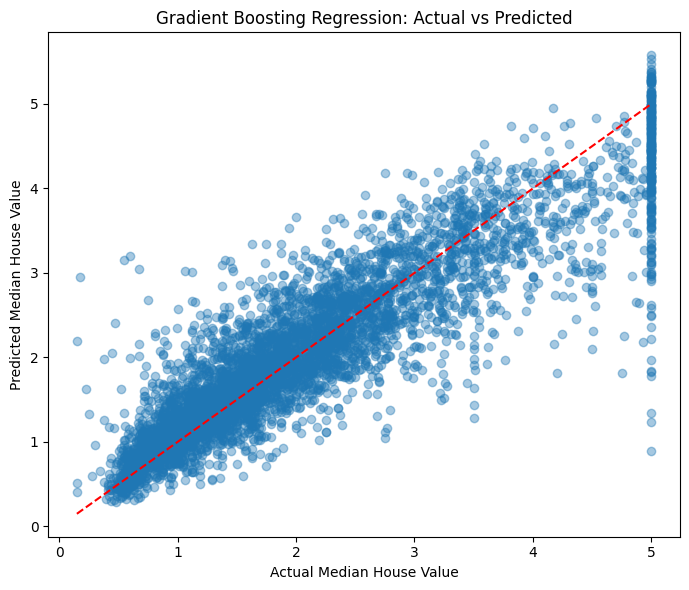

In [26]:
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, gb_reg_test_pred, alpha=0.4)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    color="red",
    linestyle="--"
)
plt.title("Gradient Boosting Regression: Actual vs Predicted")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.tight_layout()
plt.show()

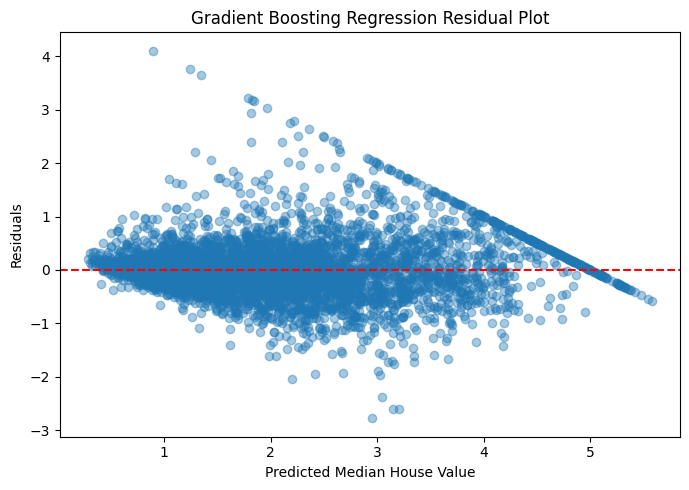

In [27]:
gb_reg_residuals = y_reg_test - gb_reg_test_pred

plt.figure(figsize=(7, 5))
plt.scatter(gb_reg_test_pred, gb_reg_residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Gradient Boosting Regression Residual Plot")
plt.xlabel("Predicted Median House Value")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

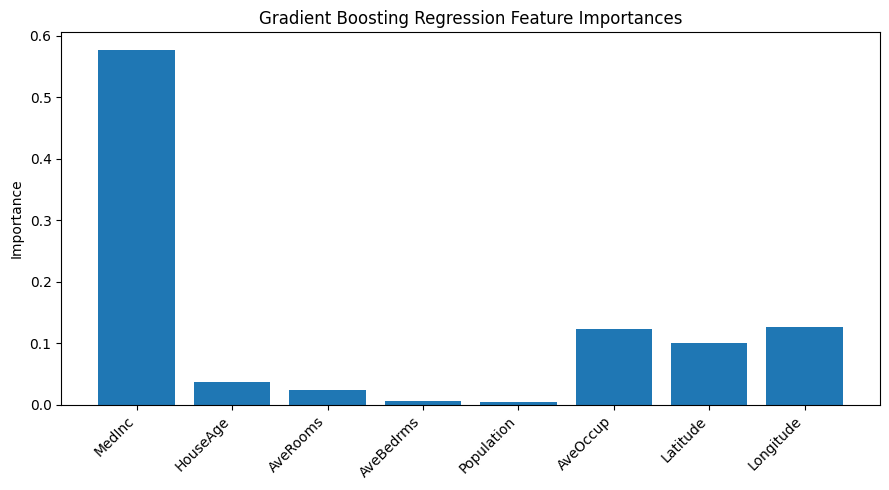

In [28]:
gb_reg_feature_importances = gb_reg.feature_importances_

plt.figure(figsize=(9, 5))
plt.bar(california.feature_names, gb_reg_feature_importances)
plt.title("Gradient Boosting Regression Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
